In [ ]:
!pip install fairlearn
!pip install catboost
!pip install category_encoders

In [ ]:
from fairlearn.datasets import fetch_acs_income

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer

In [ ]:
#algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,  #
    Lasso,  #
    ElasticNet,
    SGDRegressor,
    BayesianRidge,
    ARDRegression
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,  #
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  #
from lightgbm import LGBMRegressor  #
from catboost import CatBoostRegressor  #



In [ ]:
#testing imports
from sklearn.model_selection import cross_val_predict,  train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    explained_variance_score
)
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit


In [ ]:
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression


In [ ]:
import xgboost as xgb
import lightgbm as lgb

In [ ]:
acs_income_ds = fetch_acs_income();

income_df = acs_income_ds.frame;
print(income_df.head());
print(income_df.tail());
#no missing records, values are numeric
print(income_df.info());

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
0  18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0   1600.0
1  53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  10000.0
2  41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  24000.0
3  18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0    180.0
4  21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  29000.0
         AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
1664495  39.0  6.0  16.0  5.0  6260.0  72.0   0.0  20.0  1.0    1.0   9600.0
1664496  38.0  6.0  14.0  5.0  4251.0  72.0   0.0  32.0  1.0    8.0   2400.0
1664497  37.0  1.0  19.0  3.0  7750.0  17.0  13.0  40.0  2.0    9.0  19700.0
1664498  47.0  1.0  16.0  1.0  8990.0  72.0   1.0  40.0  1.0    8.0  18700.0
1664499  34.0  1.0  16.0  5.0  6260.0  72.0   2.0  40.0  1.0    1.0   7900.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664500 entries, 0 to 1664499
Data columns (total 11 columns):

50th percentile: $39,000
75th percentile: $68,000
90th percentile: $112,000
95th percentile: $157,000
97th percentile: $202,000
99th percentile: $432,000
99.9th percentile: $698,000


<function matplotlib.pyplot.show(close=None, block=None)>

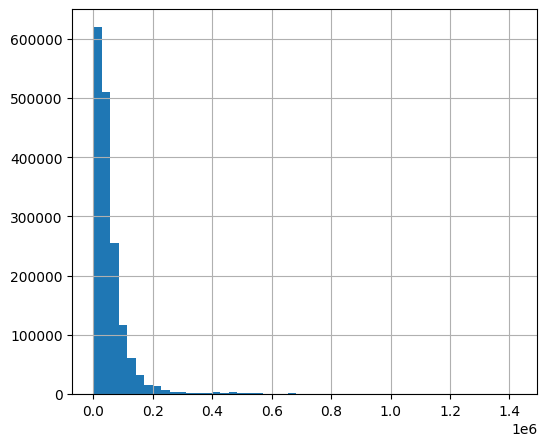

In [ ]:
#addressing outliers
for p in [50, 75, 90, 95, 97, 99, 99.9]:
    print(f"{p}th percentile: ${np.percentile(income_df['PINCP'], p):,.0f}")

income_df['PINCP'].hist(figsize=(6,5), bins=50)
plt.show

In [ ]:
income_df_out = income_df[income_df['PINCP'] <= 200000].copy()

In [ ]:
broke_df = income_df.copy()
broke_df['PINCP'] = income_df['PINCP'].clip(upper=200000)
print(broke_df.info)

<bound method DataFrame.info of          AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
0        18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0   1600.0
1        53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  10000.0
2        41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  24000.0
3        18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0    180.0
4        21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  29000.0
...       ...  ...   ...  ...     ...   ...   ...   ...  ...    ...      ...
1664495  39.0  6.0  16.0  5.0  6260.0  72.0   0.0  20.0  1.0    1.0   9600.0
1664496  38.0  6.0  14.0  5.0  4251.0  72.0   0.0  32.0  1.0    8.0   2400.0
1664497  37.0  1.0  19.0  3.0  7750.0  17.0  13.0  40.0  2.0    9.0  19700.0
1664498  47.0  1.0  16.0  1.0  8990.0  72.0   1.0  40.0  1.0    8.0  18700.0
1664499  34.0  1.0  16.0  5.0  6260.0  72.0   2.0  40.0  1.0    1.0   7900.0

[1664500 rows x 11 columns]>


In [ ]:
rich_df =  income_df[income_df['PINCP'] >= 170000]
print(rich_df.info)

<bound method DataFrame.info of          AGEP  COW  SCHL  MAR    OCCP   POBP  RELP  WKHP  SEX  RAC1P     PINCP
216      64.0  1.0  18.0  3.0  7700.0  303.0  16.0  35.0  1.0    1.0  391000.0
636      64.0  1.0  18.0  3.0  7700.0  303.0  16.0  35.0  1.0    1.0  391000.0
816      66.0  2.0  22.0  1.0   420.0   35.0   0.0  40.0  1.0    1.0  393100.0
817      67.0  6.0  19.0  1.0   350.0   13.0   1.0  50.0  2.0    1.0  350000.0
839      51.0  1.0  22.0  1.0    52.0    6.0   1.0  60.0  1.0    1.0  391000.0
...       ...  ...   ...  ...     ...    ...   ...   ...  ...    ...       ...
1664388  64.0  1.0  23.0  1.0   205.0   37.0   0.0  60.0  1.0    1.0  192000.0
1664448  39.0  1.0  23.0  3.0  2100.0   72.0  13.0  60.0  2.0    1.0  180000.0
1664449  49.0  7.0  23.0  1.0  3090.0   72.0   0.0  60.0  1.0    1.0  180000.0
1664450  47.0  1.0  22.0  1.0   120.0   72.0   1.0  50.0  2.0    1.0  180000.0
1664469  44.0  1.0  21.0  1.0   960.0   72.0   0.0  40.0  2.0    1.0  180000.0

[73233 rows x 11 co

In [ ]:
income_X = income_df.drop(["PINCP"], axis=1);
income_y = income_df["PINCP"].copy();

broke_X = broke_df.drop(["PINCP"], axis=1);
broke_y = broke_df["PINCP"].copy();

rich_X = rich_df.drop(["PINCP"], axis=1);
rich_y = rich_df["PINCP"].copy();

In [ ]:
#split broke dataset into training and test sets
X = income_X.loc[:, :]
y = income_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    incomeX_train = X.iloc[train_idx]
    incomeX_test = X.iloc[test_idx]
    incomey_train = y.iloc[train_idx]
    incomey_test = y.iloc[test_idx]

In [ ]:
#split broke dataset into training and test sets
X = broke_X.loc[:, :]
y = broke_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    brokeX_train = X.iloc[train_idx]
    brokeX_test = X.iloc[test_idx]
    brokey_train = y.iloc[train_idx]
    brokey_test = y.iloc[test_idx]

In [ ]:
#split rich dataset into training and test sets
X = rich_X.loc[:, :]
y = rich_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    richX_train = X.iloc[train_idx]
    richX_test = X.iloc[test_idx]
    richy_train = y.iloc[train_idx]
    richy_test = y.iloc[test_idx]

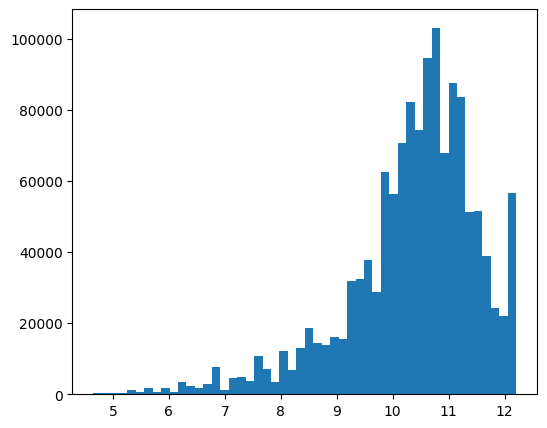

In [ ]:
brokey_train_log = np.log1p(brokey_train)
brokey_test_log = np.log1p(brokey_test)

plt.figure(figsize=(6,5))
plt.hist(brokey_train_log, bins=50)
plt.show()

In [ ]:
#Cross Validation Training Metrics Function
def regression_evaluation(X_train, y_train, algorithm, k, scaler=None):
    y_true = np.asarray(y_train).reshape(-1)
    cv_preds = cross_val_predict(algorithm, X_train, y_true, cv=k, method='predict')
    cv_preds = np.asarray(cv_preds).reshape(-1)

    # If a scaler was used, inverse transform first
    if scaler is not None:
        cv_preds = scaler.inverse_transform(cv_preds.reshape(-1, 1)).reshape(-1)
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(-1)

    #when log applied to target
    cv_preds = np.expm1(cv_preds)
    y_true = np.expm1(y_true)

    print("Prediction shape:", cv_preds.shape)

    mse = mean_squared_error(y_true, cv_preds)
    mae = mean_absolute_error(y_true, cv_preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, cv_preds)
    r2 = r2_score(y_true, cv_preds)
    evs = explained_variance_score(y_true, cv_preds)

    y_range = np.max(y_true) - np.min(y_true)
    y_std = np.std(y_true)

    eps = 1e-8

    mae_01_range = mae / (y_range + eps)
    rmse_01_range = rmse / (y_range + eps)
    mse_01_range = mse / ((y_range ** 2) + eps)

    mae_01_std = mae / (y_std + eps)
    rmse_01_std = rmse / (y_std + eps)
    mse_01_std = mse / ((y_std ** 2) + eps)

    #print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    #print(f"MAPE: {mape:.4f}")
    print(f"R^2:  {r2:.4f}")
    #print(f"EVS:  {evs:.4f}")


In [ ]:
def testing_evaluation(X_train, X_test, y_train, y_test, algorithm):
  model = algorithm
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  y_pred = np.expm1(y_pred)
  y_test = np.expm1(y_test)

  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"MAE:  {mae:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R^2:  {r2:.4f}")

  return model

In [ ]:
algorithms = {
    "Ridge": Ridge(),
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    #"RandomForest": RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=50, verbose=0, random_state=42),
}
for name, alg in algorithms.items():
  print(name, '\n')
  #nothing applied to target
  regression_evaluation(brokeX_train, brokey_train_log, alg, 3)
  #testing_evaluation(X_train, X_test, y_train, y_test, alg)
  print('\n')



Ridge 

Prediction shape: (1331600,)
MAE:  25648.9686
RMSE: 42937.2309
R^2:  0.1350


Linear Regression 

Prediction shape: (1331600,)
MAE:  25648.9674
RMSE: 42937.2275
R^2:  0.1350


Lasso 

Prediction shape: (1331600,)
MAE:  27579.7927
RMSE: 45059.8716
R^2:  0.0474


XGBoost 

Prediction shape: (1331600,)
MAE:  19946.5528
RMSE: 32092.6608
R^2:  0.5168


LightGBM 

Prediction shape: (1331600,)
MAE:  20563.2639
RMSE: 33092.1090
R^2:  0.4862


CatBoost 

Prediction shape: (1331600,)
MAE:  20214.2968
RMSE: 32428.0293
R^2:  0.5066




In [ ]:
algorithm = XGBRegressor(n_estimators=50, verbosity=0, random_state=42)
broke_model = testing_evaluation(brokeX_train, brokeX_test, brokey_train_log, brokey_test_log, algorithm)

MAE:  19953.8650
RMSE: 32118.8079
R^2:  0.5154


In [ ]:
#Model 2 time
print(richy_train.info())
print(richy_train.head())

<class 'pandas.core.series.Series'>
Index: 58586 entries, 102217 to 286295
Series name: PINCP
Non-Null Count  Dtype  
--------------  -----  
58586 non-null  float64
dtypes: float64(1)
memory usage: 915.4 KB
None
102217     185600.0
252579     570000.0
1199901    425500.0
890571     445000.0
1516600    420000.0
Name: PINCP, dtype: float64


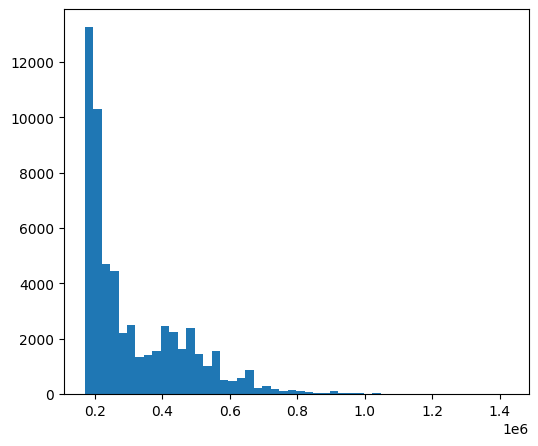

In [ ]:
plt.figure(figsize=(6,5))
plt.hist(richy_train, bins=50)
plt.show()

In [ ]:
richy_train_log = np.log1p(richy_train)
richy_test_log = np.log1p(richy_test)

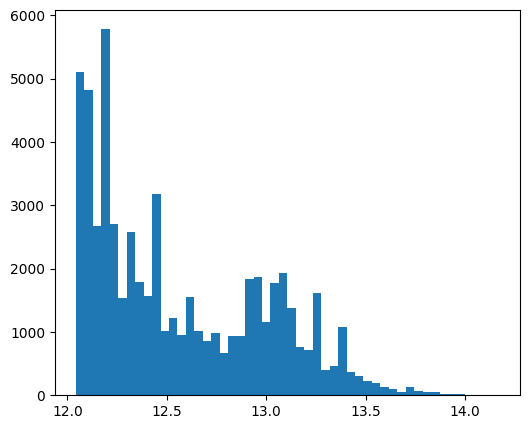

In [ ]:
plt.figure(figsize=(6,5))
plt.hist(richy_train_log, bins=50)
plt.show()

In [ ]:
algorithms = {
    "Ridge": Ridge(),
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    #"RandomForest": RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=50, verbose=0, random_state=42),
}

for name, alg in algorithms.items():
  print(name, '\n')
  regression_evaluation(richX_train, richy_train_log, alg, 3, scaler=None)
  print('\n')

Ridge 

Prediction shape: (58586,)
MAE:  117895.4721
RMSE: 156984.5108
R^2:  -0.0133


Linear Regression 

Prediction shape: (58586,)
MAE:  117895.4623
RMSE: 156984.4939
R^2:  -0.0133


Lasso 

Prediction shape: (58586,)
MAE:  120158.1264
RMSE: 158917.2823
R^2:  -0.0384


XGBoost 

Prediction shape: (58586,)
MAE:  110237.5456
RMSE: 150522.7899
R^2:  0.0684


LightGBM 

Prediction shape: (58586,)
MAE:  110635.4422
RMSE: 150583.3523
R^2:  0.0677


CatBoost 

Prediction shape: (58586,)
MAE:  110528.8142
RMSE: 150558.9903
R^2:  0.0680




In [ ]:
richX_train_feat = richX_train.copy()
richX_test_feat = richX_test.copy()

In [ ]:
# Get Model 1's predictions on the high-income training rows
#rich_X['m1_pred'] = broke_model.predict(X_high)

# Add it as a feature for Model 2
#X_high_aug = pd.concat([X_high, df_high[['m1_pred']]], axis=1)
algorithm = LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)
rich_model = testing_evaluation(richX_train, richX_test, richy_train_log, richy_test_log, algorithm)


MAE:  109437.5298
RMSE: 149029.0372
R^2:  0.0730


In [ ]:
def predict(X_input):
    broke_pred = broke_model.predict(X_input)
    broke_pred_real = np.expm1(broke_pred)

    final_preds = []
    for i, pred in enumerate(broke_pred_real):
        if pred >= 270000:
            row_aug = X_input.iloc[[i]].copy()
            #row_aug['m1_pred'] = pred
            #row_aug['WKHPxAGEP'] = X_input.iloc[i]['WKHP'] * X_input.iloc[i]['AGEP']
            # make pred inbetween 0 and 50000 and standardize
            #weight = pred
            #weight -= 300000
            #weight = np.clip(weight, 0, 50000) / 50000
            #final_preds.append(rich_model.predict(row_aug)[0] * weight + pred * (1-weight))
            log_pred = rich_model.predict(row_aug)[0]
            final_preds.append(np.expm1(log_pred))
        else:
            final_preds.append(pred)

    return final_preds

In [ ]:
predictions = predict(incomeX_test)
mae = mean_absolute_error(incomey_test, predictions)
rmse = np.sqrt(mean_squared_error(incomey_test, predictions))
r2 = r2_score(incomey_test, predictions)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  25231.2297
RMSE: 60668.3569
R^2:  0.3104


In [ ]:
print(rich_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 73233 entries, 216 to 1664469
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGEP    73233 non-null  float64
 1   COW     73233 non-null  float64
 2   SCHL    73233 non-null  float64
 3   MAR     73233 non-null  float64
 4   OCCP    73233 non-null  float64
 5   POBP    73233 non-null  float64
 6   RELP    73233 non-null  float64
 7   WKHP    73233 non-null  float64
 8   SEX     73233 non-null  float64
 9   RAC1P   73233 non-null  float64
 10  PINCP   73233 non-null  float64
dtypes: float64(11)
memory usage: 6.7 MB
None


In [ ]:
def train_ensemble(X_train, y_train_log, X_val, y_val_log):
    """
    Train XGBoost, LightGBM, and CatBoost on log-transformed targets,
    then convert predictions back to original scale for evaluation.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, r2_score

    models = {}
    predictions = {}

    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

    y_val = np.expm1(y_val_log)

    # ===== XGBoost Model =====
    print("Training XGBoost...")
    xgb_model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        verbosity=0,
        early_stopping_rounds=100
    )

    xgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        verbose=False
    )

    xgb_preds_log = xgb_model.predict(X_val_np)
    xgb_preds = np.expm1(xgb_preds_log)
    xgb_mae = mean_absolute_error(y_val, xgb_preds)
    xgb_r2 = r2_score(y_val, xgb_preds)
    print(f"XGBoost - MAE: {xgb_mae:.4f}, R²: {xgb_r2:.4f}")

    models['xgb'] = xgb_model
    predictions['xgb'] = xgb_preds

    # ===== LightGBM Model =====
    print("Training LightGBM...")
    lgb_model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    lgb_preds_log = lgb_model.predict(X_val_np)
    lgb_preds = np.expm1(lgb_preds_log)
    lgb_mae = mean_absolute_error(y_val, lgb_preds)
    lgb_r2 = r2_score(y_val, lgb_preds)
    print(f"LightGBM - MAE: {lgb_mae:.4f}, R²: {lgb_r2:.4f}")

    models['lgb'] = lgb_model
    predictions['lgb'] = lgb_preds

    # ===== CatBoost Model =====
    print("Training CatBoost...")
    cb_model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.1,
        depth=6,
        subsample=0.8,
        reg_lambda=10,
        random_state=42,
        verbose=0
    )

    cb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        early_stopping_rounds=100,
        verbose=False
    )

    cb_preds_log = cb_model.predict(X_val_np)
    cb_preds = np.expm1(cb_preds_log)
    cb_mae = mean_absolute_error(y_val, cb_preds)
    cb_r2 = r2_score(y_val, cb_preds)
    print(f"CatBoost - MAE: {cb_mae:.4f}, R²: {cb_r2:.4f}")

    models['catboost'] = cb_model
    predictions['catboost'] = cb_preds

    # ===== Ensemble Predictions =====
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    ensemble_mae = mean_absolute_error(y_val, ensemble_preds)
    ensemble_r2 = r2_score(y_val, ensemble_preds)
    print(f"\nENSEMBLE (Average) - MAE: {ensemble_mae:.4f}, R²: {ensemble_r2:.4f}")
    print(f"Ensemble improvement over best single model: {ensemble_r2 - max(xgb_r2, lgb_r2, cb_r2):.4f} R² change")

    predictions['ensemble'] = ensemble_preds

    return models, predictions

In [ ]:
# Split X_train into train/val for ensemble training (don't touch X_test!)
X_tr, X_val, y_tr, y_val = train_test_split(incomeX_train, incomey_train, test_size=0.2, random_state=42)
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)
models_dict, val_predictions = train_ensemble(X_tr, y_tr_log, X_val, y_val_log)

Training XGBoost...
XGBoost - MAE: 24533.9137, R²: 0.3875
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1200]	valid_0's l2: 0.519715


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - MAE: 24460.1451, R²: 0.3889
Training CatBoost...
CatBoost - MAE: 24599.1279, R²: 0.3803

ENSEMBLE (Average) - MAE: 24457.5740, R²: 0.3871
Ensemble improvement over best single model: -0.0018 R² change


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(brokeX_train, brokey_train, test_size=0.2, random_state=42)
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)
broke_models_dict, val_predictions = train_ensemble(X_tr, y_tr_log, X_val, y_val_log)

Training XGBoost...
XGBoost - MAE: 19476.5234, R²: 0.5364
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1200]	valid_0's l2: 0.485707


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - MAE: 19427.1461, R²: 0.5385
Training CatBoost...
CatBoost - MAE: 19580.6923, R²: 0.5317

ENSEMBLE (Average) - MAE: 19434.2287, R²: 0.5377
Ensemble improvement over best single model: -0.0008 R² change


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(richX_train, richy_train, test_size=0.2, random_state=42)
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)
rich_models_dict, val_predictions = train_ensemble(X_tr, y_tr_log, X_val, y_val_log)

Training XGBoost...
XGBoost - MAE: 110512.6203, R²: 0.0732
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[210]	valid_0's l2: 0.166049
LightGBM - MAE: 110431.2116, R²: 0.0743
Training CatBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost - MAE: 110385.1374, R²: 0.0746

ENSEMBLE (Average) - MAE: 110353.9599, R²: 0.0759
Ensemble improvement over best single model: 0.0013 R² change


In [ ]:
def predict(X_input):
    broke_pred = broke_models_dict['lgb'].predict(X_input)
    broke_pred_real = np.expm1(broke_pred)

    final_preds = []
    for i, pred in enumerate(broke_pred_real):
        if pred >= 170000:
            row_aug = X_input.iloc[[i]].copy()

            log_pred = rich_models_dict['lgb'].predict(row_aug)[0]
            final_preds.append(np.expm1(log_pred))
        else:
            final_preds.append(pred)

    return final_preds

predictions = predict(incomeX_test)
mae = mean_absolute_error(incomey_test, predictions)
r2 = r2_score(incomey_test, predictions)

print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  24639.2877
R^2:  0.3431
